In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

df=sns.load_dataset('titanic')
df.shape

(891, 15)

In [5]:
df.columns.tolist()

['survived',
 'pclass',
 'sex',
 'age',
 'sibsp',
 'parch',
 'fare',
 'embarked',
 'class',
 'who',
 'adult_male',
 'deck',
 'embark_town',
 'alive',
 'alone']

In [6]:
columns_to_keep = [
    'survived',
    'pclass',
    'sex',
    'age',
    'sibsp',
    'parch',
    'fare',
    'embarked',
]

df=df[columns_to_keep]
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [10]:
df.isna().sum()

survived      0
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
dtype: int64

In [11]:
age_median=df['age'].median()
embarked_mode=df['embarked'].mode()[0]

df['age']=df['age'].fillna(age_median)
df['embarked']=df['embarked'].fillna(embarked_mode)

print(f'Медиана возраста: {age_median}')
print(f'Мода порта: {embarked_mode}')
print()
print(df.isna().sum())

Медиана возраста: 28.0
Мода порта: S

survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64


In [12]:
df= pd.get_dummies(df, columns=['sex', 'embarked'], drop_first=False)

print('Колонки после кодирования:')
print(df.columns.tolist())
print()
df.head()

Колонки после кодирования:
['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_female', 'sex_male', 'embarked_C', 'embarked_Q', 'embarked_S']



,survived,pclass,age,sibsp,parch,fare,sex_female,sex_male,embarked_C,embarked_Q,embarked_S
0,0,3,22.0,1,0,7.2500,False,True,False,False,True
1,1,1,38.0,1,0,71.2833,True,False,True,False,False
2,1,3,26.0,0,0,7.9250,True,False,False,False,True
3,1,1,35.0,1,0,53.1000,True,False,False,False,True
4,0,3,35.0,0,0,8.0500,False,True,False,False,True


In [14]:
df.dtypes

survived        int64
pclass          int64
age           float64
sibsp           int64
parch           int64
fare          float64
sex_female       bool
sex_male         bool
embarked_C       bool
embarked_Q       bool
embarked_S       bool
dtype: object

In [15]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype('int')
df.dtypes

survived        int64
pclass          int64
age           float64
sibsp           int64
parch           int64
fare          float64
sex_female      int64
sex_male        int64
embarked_C      int64
embarked_Q      int64
embarked_S      int64
dtype: object

In [17]:
X=df.drop(columns='survived')
y=df['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train:', X_train.shape, 'Test:', X_test.shape)
print()
print('Доля выживших в train:', round(y_train.mean(), 4))
print('Доля выживших в test:', round(y_test.mean(), 4))

Train: (712, 10) Test: (179, 10)

Доля выживших в train: 0.3834
Доля выживших в test: 0.3855


In [20]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f'Accuracy {acc:.2%}')

Accuracy 80.45%


In [22]:
coef= pd.Series(model.coef_[0], index=X.columns)
print(coef.sort_values(ascending=False))

sex_female    1.309863
embarked_Q    0.301858
embarked_C    0.041957
fare          0.002207
age          -0.038728
parch        -0.079387
sibsp        -0.248033
embarked_S   -0.344817
pclass       -1.099611
sex_male     -1.310865
dtype: float64


[[98 12]
 [23 46]]


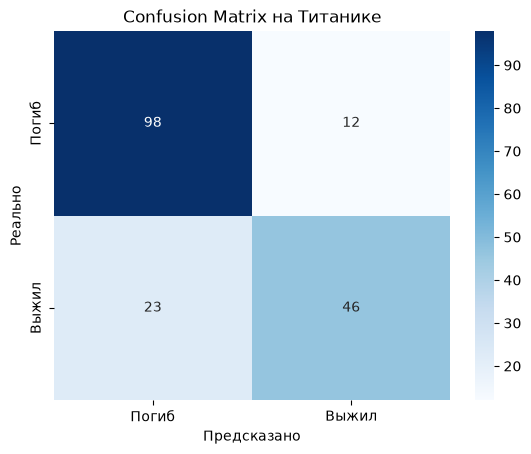

In [23]:
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(y_test, y_pred)
print(cm)

sns.heatmap(cm, annot=True, cmap='Blues', fmt='d',
            xticklabels=['Погиб', 'Выжил'],
            yticklabels=['Погиб', 'Выжил'])
plt.xlabel('Предсказано')
plt.ylabel('Реально')
plt.title('Confusion Matrix на Титанике')
plt.show()